# Week 4: Linear Regression on the Housing Dataset

## Objective

The objective of this notebook is to build a supervised machine learning model capable of predicting house prices using the Housing Prices dataset.

The workflow includes:

- Loading and preprocessing the dataset
- Encoding categorical variables
- Splitting the dataset into training and testing sets
- Training a Linear Regression model
- Making predictions
- Evaluating model performance using RMSE
- Interpreting the model coefficients

Import Libraries and Load the house dataset

In [39]:
import pandas as pd 
import numpy as np


import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
)

In [40]:
housing = pd.read_csv("../data/cleaned/housing_cleaned.csv")

In [41]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [42]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [43]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Data Preprocessing

In [44]:
housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [45]:
housing = pd.get_dummies(
    housing,
    drop_first=True,
    dtype=int
)

In [46]:
housing.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


## Feature Selection

In [47]:
x = housing.drop("price", axis=1)
y =  housing["price"]

In [48]:
x.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [49]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

## Train/Test Split

In [50]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

## Inspect the sizes 

In [51]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 13)
(109, 13)
(436,)
(109,)


In [52]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 235.97, 76778.7 ,1094444.79,..., 629890.57,-126881.82,-413645.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea_yes', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


## Make predictions on the test set

In [53]:
y_pred = model.predict(x_test)

In [54]:
predictions = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

predictions.head()

,Actual Price,Predicted Price
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06


## Evaluate the Model

In [55]:
#Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 970,043.40
Root Mean Squared Error (RMSE): 1,324,506.96
R-squared (R2): 0.65


On average, the model's predicted house price differs from the actual price by approximately KSh 970,043 an RSME of 1,324,506.96 and an R^2 of 0.65.

In [56]:
Coefficients = pd.DataFrame({
   "Feature" : x.columns,
   "Coefficient" : model.coef_
})

coefficients = Coefficients.sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


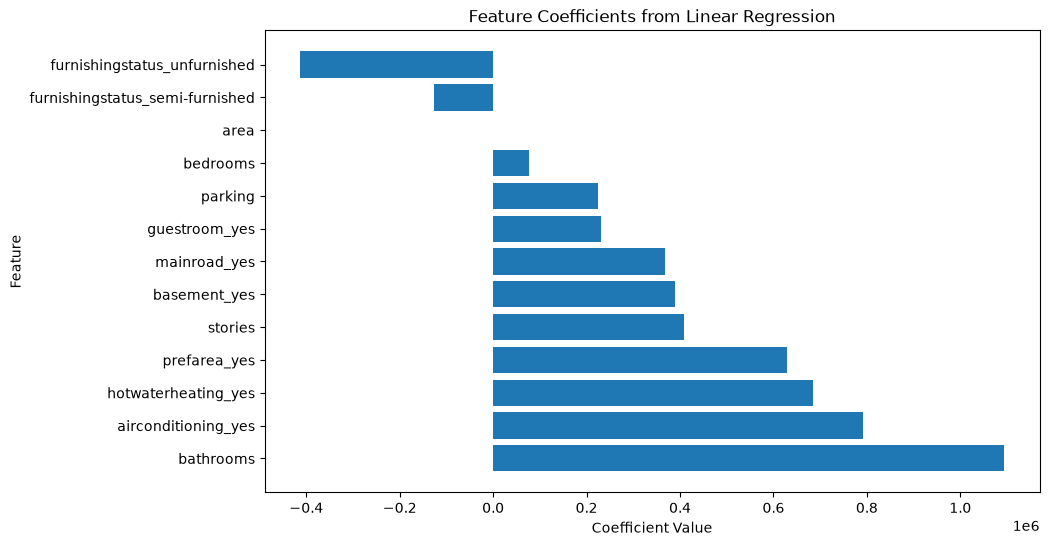

In [57]:
plt.figure(figsize=(10, 6))

plt.barh(coefficients["Feature"], coefficients["Coefficient"])

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Coefficients from Linear Regression")

plt.show()

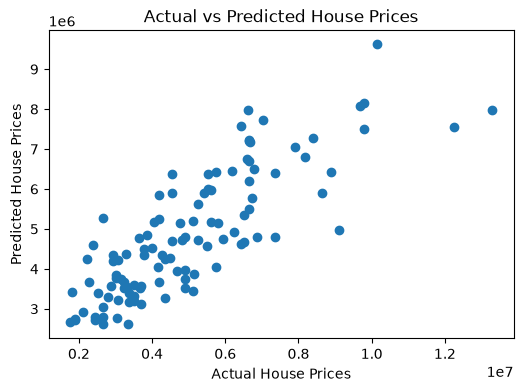

In [58]:
plt.figure(figsize=(6, 4))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

### Interpretation of Feature Coefficients

The Linear Regression model assigns a coefficient to each feature. A positive coefficient indicates that, holding other features constant, an increase in that feature is associated with an increase in the predicted house price. A negative coefficient indicates an association with a decrease in the predicted house price.

The largest positive coefficient in the model is **bathrooms**, with a coefficient of approximately **1,094,445**. This means that, holding other variables constant, an additional bathroom is associated with an estimated increase of approximately **KSh 1.09 million** in the predicted house price.

Other features with relatively large positive coefficients include:

- **airconditioning_yes:** approximately +KSh 791,427
- **hotwaterheating_yes:** approximately +KSh 684,650
- **prefarea_yes:** approximately +KSh 629,891
- **stories:** approximately +KSh 407,477
- **basement_yes:** approximately +KSh 390,251
- **mainroad_yes:** approximately +KSh 367,920

The coefficient for **area** is approximately **235.97**. Therefore, holding the other features constant, an increase of one square foot in area is associated with an estimated increase of approximately **KSh 236** in the predicted house price.

The categorical features related to furnishing status have negative coefficients:

- **furnishingstatus_semi-furnished:** approximately -KSh 126,882
- **furnishingstatus_unfurnished:** approximately -KSh 413,645

Because `drop_first=True` was used during encoding, **furnished** is the reference category. Therefore, these coefficients represent the difference in predicted price between semi-furnished or unfurnished houses and furnished houses, while holding the other features constant.

It is important to note that these coefficients represent **associations learned by the model and do not necessarily prove causation**. The magnitude of coefficients should also be interpreted carefully because the features are measured on different scales.